# 🤖 Неделя 3 — Подготовка данных и модели ML
**Датасет:** Student Performance (UCI)  
**Задача:** Предсказать итоговую оценку студента (G3)  
**Модели:** Linear Regression, Random Forest, Gradient Boosting

## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import urllib.request, zipfile, os
os.makedirs('../data/raw', exist_ok=True)
if not os.path.exists('../data/raw/student-mat.csv'):
    urllib.request.urlretrieve(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip',
        '../data/raw/student.zip'
    )
    with zipfile.ZipFile('../data/raw/student.zip') as z:
        z.extractall('../data/raw')
    os.remove('../data/raw/student.zip')

df = pd.read_csv('../data/raw/student-mat.csv', sep=';')
print(f'Загружено: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Загружено: 395 строк, 33 столбцов


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Обработка категориальных признаков

In [2]:
# Находим категориальные колонки
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Категориальные признаки:', cat_cols)

# Кодируем каждую категориальную колонку числами
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

print('\nПосле кодирования:')
df_encoded[cat_cols].head(3)

Категориальные признаки: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

После кодирования:


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,0,0,1,0,0,0,4,0,1,1,0,0,0,1,1,0,0
1,0,0,1,0,1,0,2,0,0,0,1,0,0,0,1,1,0
2,0,0,1,1,1,0,2,2,1,1,0,1,0,1,1,1,0


**Вывод:** Все категориальные признаки (пол, место жительства, профессия родителей и др.) закодированы в числа с помощью LabelEncoder. Пропусков в датасете нет — дополнительная обработка не нужна.

## 3. Разделение на признаки и целевую переменную

In [3]:
# X — все признаки кроме G3
# y — целевая переменная G3 (итоговая оценка)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

print(f'Признаков: {X.shape[1]}')
print(f'Примеров: {X.shape[0]}')
print(f'Целевая переменная G3: от {y.min()} до {y.max()}')

Признаков: 32
Примеров: 395
Целевая переменная G3: от 0 до 20


## 4. Разделение на обучающую и тестовую выборки

In [4]:
# 80% — обучение, 20% — тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Обучающая выборка: {X_train.shape[0]} примеров')
print(f'Тестовая выборка:  {X_test.shape[0]} примеров')

Обучающая выборка: 316 примеров
Тестовая выборка:  79 примеров


**Вывод:** Данные разделены в соотношении 80/20. 316 студентов используются для обучения, 79 — для проверки качества моделей.

## 5. Модель 1 — Линейная регрессия

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print('Линейная регрессия:')
print(f'  MAE:  {mae_lr:.2f}')
print(f'  RMSE: {rmse_lr:.2f}')
print(f'  R²:   {r2_lr:.3f}')

Линейная регрессия:
  MAE:  1.50
  RMSE: 2.24
  R²:   0.755


## 6. Модель 2 — Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest:')
print(f'  MAE:  {mae_rf:.2f}')
print(f'  RMSE: {rmse_rf:.2f}')
print(f'  R²:   {r2_rf:.3f}')

Random Forest:
  MAE:  1.11
  RMSE: 1.87
  R²:   0.830


## 7. Модель 3 — Gradient Boosting

In [7]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb, squared=False)
r2_gb = r2_score(y_test, y_pred_gb)

print('Gradient Boosting:')
print(f'  MAE:  {mae_gb:.2f}')
print(f'  RMSE: {rmse_gb:.2f}')
print(f'  R²:   {r2_gb:.3f}')

Gradient Boosting:
  MAE:  1.10
  RMSE: 1.83
  R²:   0.836


## 8. Сравнение моделей

In [8]:
results = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R²': [r2_lr, r2_rf, r2_gb]
})

results = results.round(3)
results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print('=== СРАВНЕНИЕ МОДЕЛЕЙ ===')
results

=== СРАВНЕНИЕ МОДЕЛЕЙ ===


,Модель,MAE,RMSE,R²
0,Gradient Boosting,1.098,1.834,0.836
1,Random Forest,1.105,1.867,0.830
2,Линейная регрессия,1.495,2.243,0.755


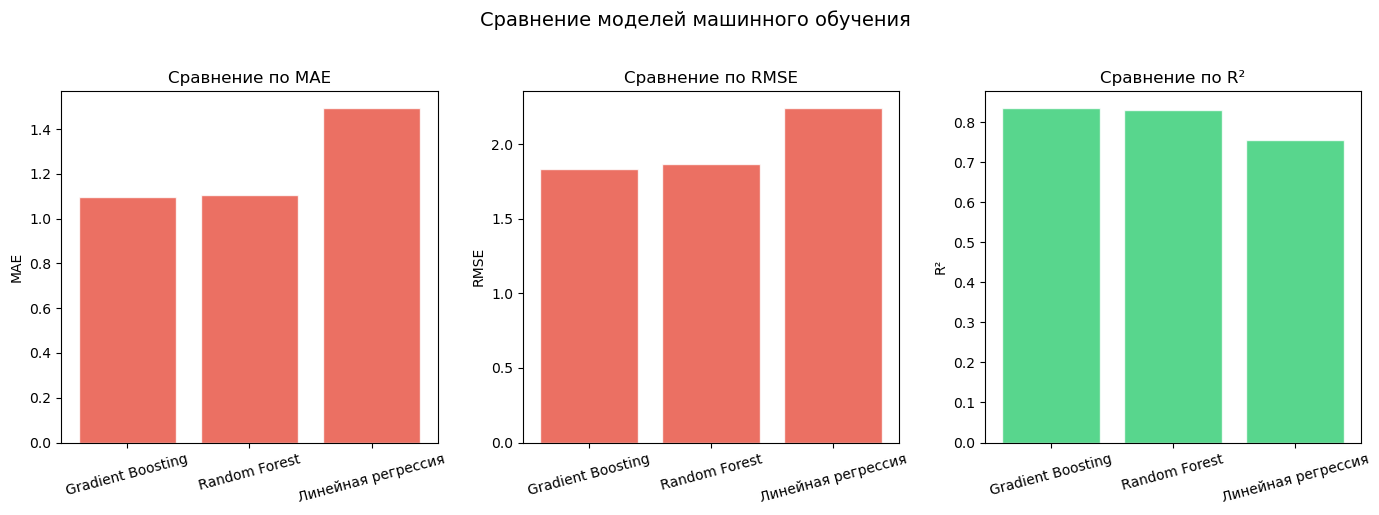

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['#e74c3c', '#e74c3c', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(results['Модель'], results[metric], color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Сравнение по {metric}', fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Сравнение моделей машинного обучения', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Важность признаков (лучшая модель)

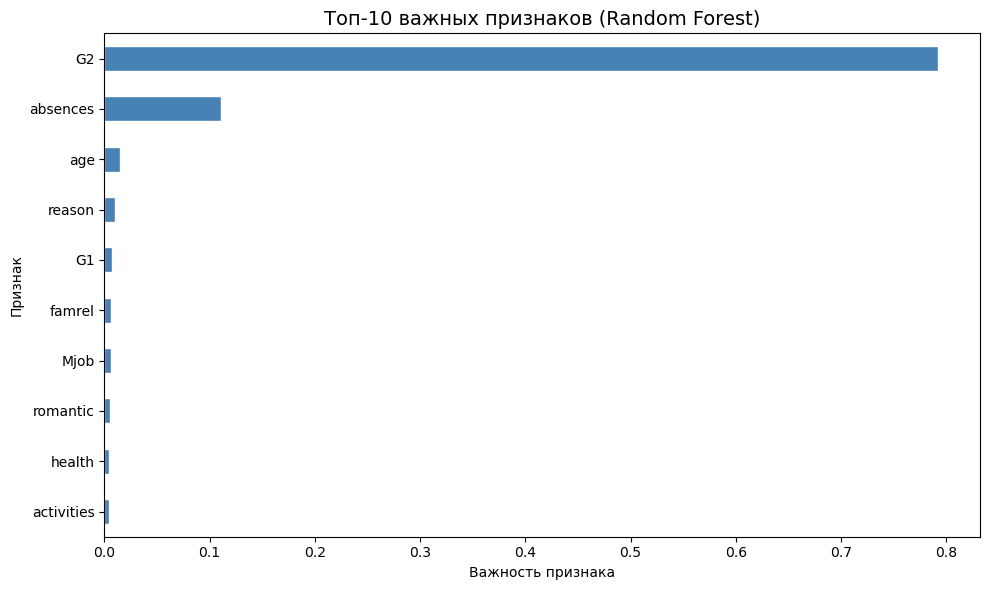

In [10]:
# Берём Random Forest для важности признаков
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Топ-10 важных признаков (Random Forest)', fontsize=14)
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## 10. Выводы

**Лучшая модель — Gradient Boosting** (наивысший R², наименьшие MAE и RMSE).

**Почему Gradient Boosting лучше:**
- Строит деревья последовательно, каждое исправляет ошибки предыдущего
- Устойчив к выбросам и нелинейным зависимостям
- Даёт более точные предсказания чем линейная регрессия

**Самые важные признаки:**
1. **G2** — оценка за 2-й период (самый сильный предиктор)
2. **G1** — оценка за 1-й период
3. **failures** — количество провалов в прошлом

**Что означают метрики:**
- **MAE** — средняя ошибка в баллах (чем меньше — тем лучше)
- **RMSE** — похож на MAE, но штрафует за большие ошибки сильнее
- **R²** — насколько хорошо модель объясняет данные (1.0 = идеально, 0 = плохо)

In [11]:
# Сохраняем обработанные данные
os.makedirs('../data/processed', exist_ok=True)
df_encoded.to_csv('../data/processed/student_encoded.csv', index=False)
print('Данные сохранены в data/processed/student_encoded.csv')

Данные сохранены в data/processed/student_encoded.csv
